In [90]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io

In [91]:
#Descargar set de datos de Fashion MNIST de Zalando
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

# A que se refieren los parametros
- as_supervised = True : devuelve los datos como tuplas (imagen, etiqueta) en lugar de un diccionario.
- with_info = True : devuelve también un objeto con metadatos del dataset (clases, cantidad de ejemplos, etc.).

In [92]:
#Imprimir los metadatos para ver la informacion del set
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\franc\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [93]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [94]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [95]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255 # pasa de 0-255 a 0-1
    return imagenes, etiquetas

In [96]:
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

# Escribe para que se utiliza la funcion map
- Es para aplicar la función que hicimos en la celda pasada llamada normalizar a cada elemento del dataset.

In [97]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

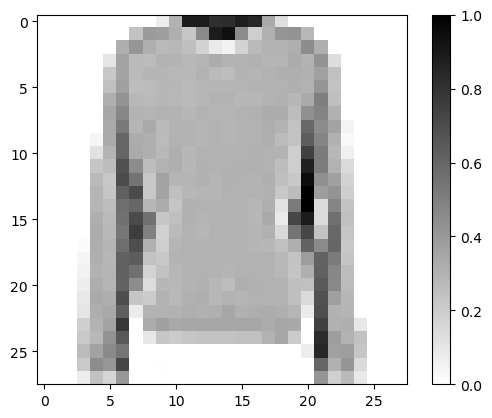

In [98]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28,28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

In [99]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [100]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [101]:
TAMANO_LOTE = 32

In [102]:
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [103]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [104]:
historial = modelo.fit(datos_entrenamiento, epochs=5, steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8158 - loss: 0.5207
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8606 - loss: 0.3841
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8734 - loss: 0.3483
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8799 - loss: 0.3279
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8867 - loss: 0.3094


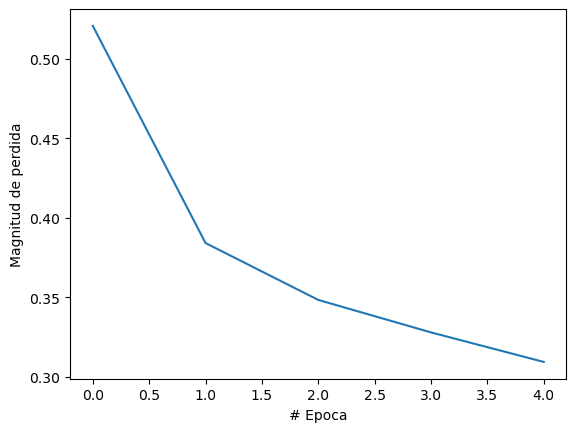

In [105]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de perdida")
plt.plot(historial.history["loss"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


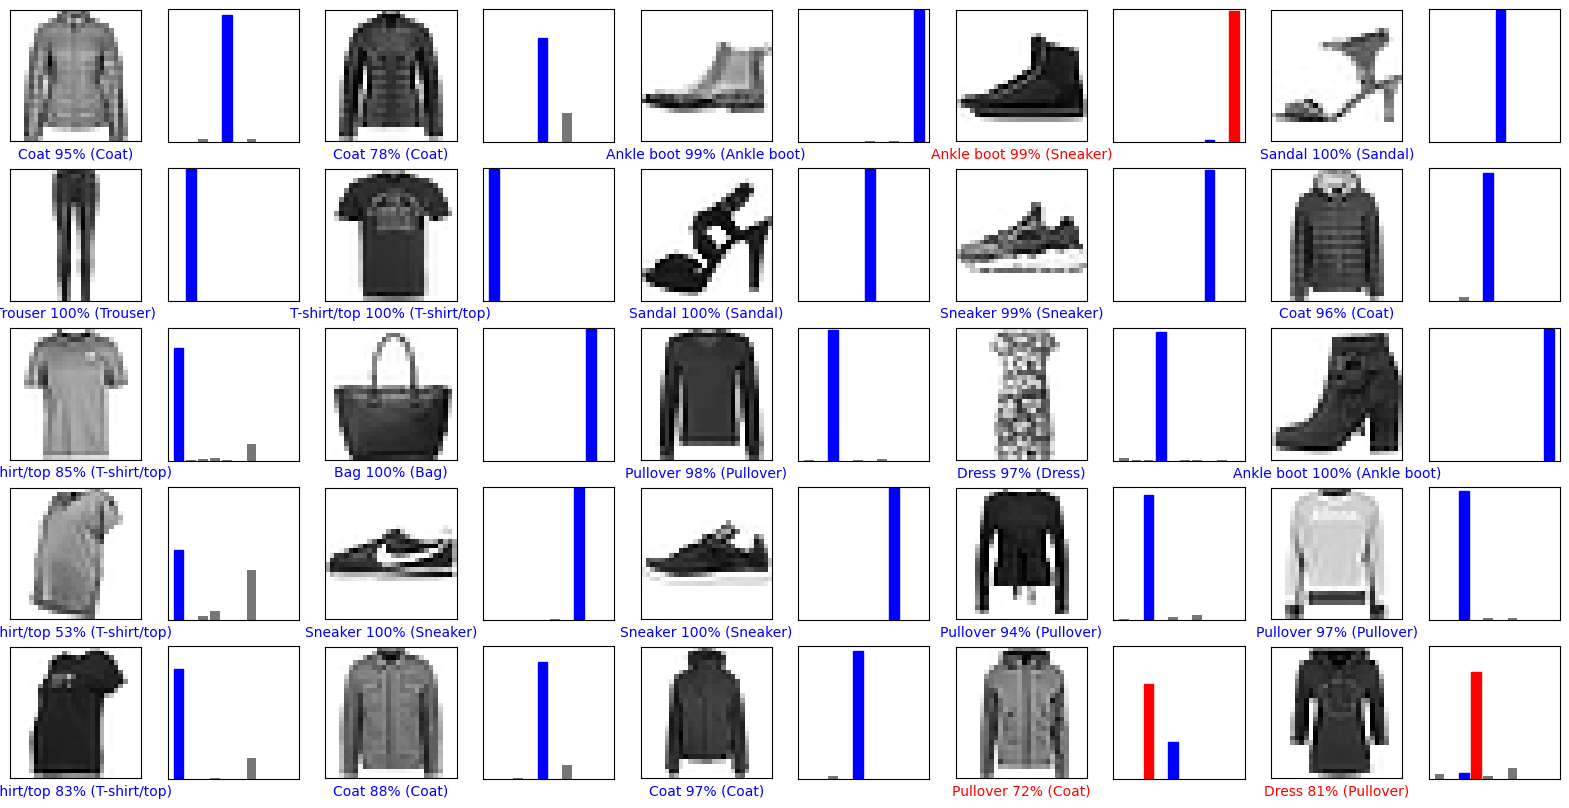

In [106]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)

    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(
        nombres_clases[etiqueta_prediccion],
        100*np.max(arr_predicciones),
        nombres_clases[etiqueta_real]),
        color=color
    )

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0,1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

In [111]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediccion: Dress


In [125]:
nombres_clases_usuario = [
    'Camiseta',
    'Pantalón',
    'Suéter',
    'Vestido',
    'Saco',
    'Sandalia',
    'Camisa',
    'Tenis',
    'Bolsa',
    'Botín'
]

In [121]:
uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [119]:
def preprocesar_imagen_usuario(contenido):
    img = Image.open(io.BytesIO(contenido)).convert('L')  # escala de grises
    img = img.resize((28, 28))
    img_array = np.array(img).astype('float32') / 255.0

    # Invertir colores si la prenda está oscura sobre fondo claro
    img_array = 1.0 - img_array

    # Mostrar imagen procesada
    plt.figure(figsize=(3,3))
    plt.imshow(img_array, cmap='gray')
    plt.title("Imagen procesada")
    plt.axis('off')
    plt.show()

    # Dar formato para el modelo
    img_array = img_array.reshape(1, 28, 28, 1)
    return img_array

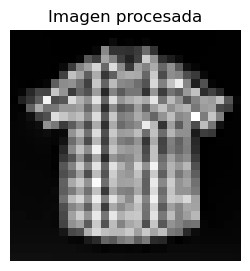

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicción: Camisa
Confianza: 56.73%


In [126]:
if len(uploader.value) > 0:
    archivo = uploader.value[0]
    contenido = archivo['content']

    imagen_usuario = preprocesar_imagen_usuario(contenido)
    prediccion = modelo.predict(imagen_usuario)

    indice = np.argmax(prediccion[0])
    confianza = np.max(prediccion[0]) * 100

    print("Predicción:", nombres_clases_usuario[indice])
    print("Confianza: {:.2f}%".format(confianza))
else:
    print("Sube una imagen.")

# ¿Qué es el formato H5?

**H5 (HDF5 - Hierarchical Data Format version 5)** es un formato de archivo binario 
diseñado para almacenar grandes cantidades de datos numéricos de forma eficiente.

**Estructura:** jerárquica, similar a un sistema de archivos con grupos y datasets.

**Sirve para guardar:**
- La arquitectura del modelo (capas y configuración)
- Los pesos entrenados
- El estado del optimizador
- La configuración de compilación

**Ventajas:**
- Portable (funciona en cualquier SO)
- Eficiente (soporta compresión)
- Estándar en Deep Learning
- Extensión: .h5 o .hdf5

In [127]:
modelo.save("modelo_tienda_ropa.h5")
print("Modelo guardado en formato .h5")

Modelo guardado en formato .h5
